In [5]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm # for oceanography-specific colormaps
from scipy.io import loadmat
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd
from scipy.io import loadmat
from scipy.interpolate import RegularGridInterpolator

### Functions

#### Dist2coast

In [6]:
##--------------------- Distance to the coast -----------------------##
def _islatlon(lat, lon):
    """
    Rough MATLAB-style range check:  -90 ≤ lat ≤ 90  and  -180 ≤ lon ≤ 360
    """
    return (np.all(lat >= -90) and np.all(lat <= 90) and
            np.all(lon >= -180) and np.all(lon <= 360))


def dist2coast(lati, loni, *, matfile="/gxfs_work/geomar/smomw662/NHCS/Master_Thesis/distance2coast.mat"):
    """
    dist2coast  –  Great-circle distance [km] from any point(s) to the nearest coastline.
    
    Parameters
    ----------
    lati, loni : array-like
        Latitudes and longitudes of the target points (same shape, any dimensionality).
    matfile : str, optional
        Path to the `distance2coast.mat` file containing variables
        `lat`, `lon`, and `D` (pre-computed distance grid).

    Returns
    -------
    di : ndarray
        Array of the same shape as `lati`/`loni` with distances in kilometres.
    """
    # Convert inputs to ndarray, preserve original shape for the return
    lati = np.asanyarray(lati, dtype=float)
    loni = np.asanyarray(loni, dtype=float)

    # --- Error checks (MATLAB narginchk / asserts) ------------------------
    if lati.shape != loni.shape:
        raise ValueError("Dimensions of input coordinates must agree.")
    if not _islatlon(lati, loni):
        raise ValueError(
            "Input coordinates appear to be outside the normal latitude/longitude "
            "ranges. Check inputs (and their order) and try again."
        )

    # --- Wrap any 0↠360 longitudes into -180↠180 --------------------------
    loni = np.where(loni > 180, loni - 360, loni)

    # --- Load coastline-distance grid from .mat ---------------------------
    mat = loadmat(matfile)
    lat = mat["lat"].ravel()        # 1-D vectors
    lon = mat["lon"].ravel()
    D   = mat["D"]                  # 2-D matrix, same dims as (lat, lon)

    # --- Wrap the data set itself for seamless Date-Line interpolation ----
    D_wrap  = np.concatenate([D[:, -5:], D, D[:, :5]], axis=1)  # MATLAB: end-4:end, 1:5
    lon_wrap = np.concatenate([lon[-5:] - 360, lon, lon[:5] + 360])

    # --- Linear 2-D interpolation (RegularGridInterpolator) ---------------
    interp = RegularGridInterpolator(
        (lat, lon_wrap),
        D_wrap.astype(float),
        method="linear",
        bounds_error=False,
        fill_value=np.nan,   # mirror MATLAB’s NaN outside the grid
    )

    # Sample the interpolant at the requested points
    pts = np.column_stack((lati.ravel(), loni.ravel()))
    di  = interp(pts).reshape(lati.shape)

    return di #in km


#### Inshore mask

In [66]:
## kml to struct
import re
from xml.etree import ElementTree as ET
import numpy as np

def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [67]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK111km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

In [33]:
ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})

mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)
expanded_mask = np.tile(mask_nan[np.newaxis, :, :], (432, 1, 1))

In [70]:
LON, LAT = np.meshgrid(ds.lon_rho.compute().values[0,:],ds.lat_rho.compute().values[:,0])
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

### Upwelling

In [54]:
time = pd.date_range(start="1980-01",end="2016-01",freq='M')
WMLD_data = loadmat("../../NHCS/Processed/WMLD_MLD.mat")
# print(WMLD_data.keys())

WMLD_ds_ = xr.Dataset(
    data_vars={
        'WMLD': (("time", "lat","lon"), WMLD_data['WMLD'].transpose(2, 0, 1)*expanded_mask),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

WMLD_ds_

/tmp/ipykernel_572029/2668870750.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start="1980-01",end="2016-01",freq='M')


<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    WMLD     (time, lat, lon) float64 1GB 4.613e-08 4.613e-08 ... nan nan

### Mixed Layer depth

In [55]:
MLD = loadmat("../../NHCS/Processed/WMLD_MLD.mat")

MLD_ds = xr.Dataset(
    data_vars={
        'MLD': (("time", "lat","lon"), MLD['MLD'].transpose(2, 1, 0)*expanded_mask),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

MLD_ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 1GB 0.9402 0.9402 1.335 ... nan nan nan

### Distance to coast

In [13]:
LON, LAT = np.meshgrid(WMLD_ds_.lon,WMLD_ds_.lat)
D=dist2coast(LAT,LON)

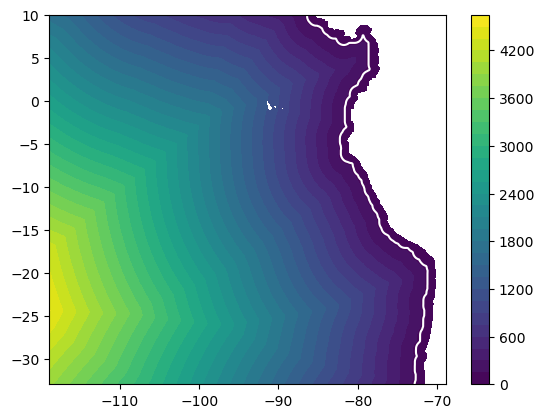

In [52]:
plt.contourf(LON,LAT,D*mask_nan,levels=40)
plt.colorbar()
plt.contour(LON,LAT,D,[111],colors='white')

### Pre Sverdrup calculation
* This is not the right way but I keep it anyways

In [98]:
D_ds = xr.Dataset(
    data_vars={
        'D': (("lat","lon"), D*mask_nan),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
}
)

D_ds

<xarray.Dataset> Size: 3MB
Dimensions:  (lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
Data variables:
    D        (lat, lon) float64 3MB 3.937e+03 3.931e+03 3.925e+03 ... nan nan

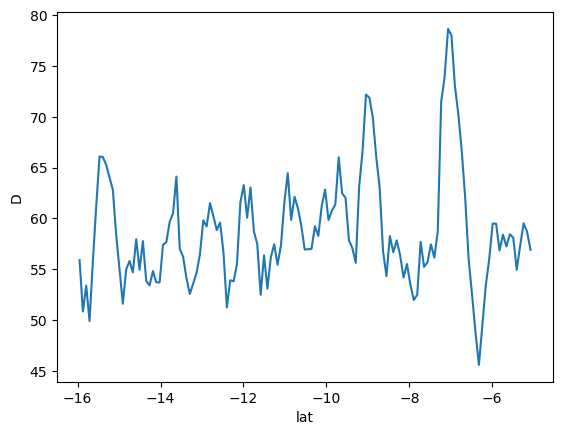

In [102]:
(D_ds.D * inshore_mask).mean('lon').sel(lat=slice(-16,-5)).plot()

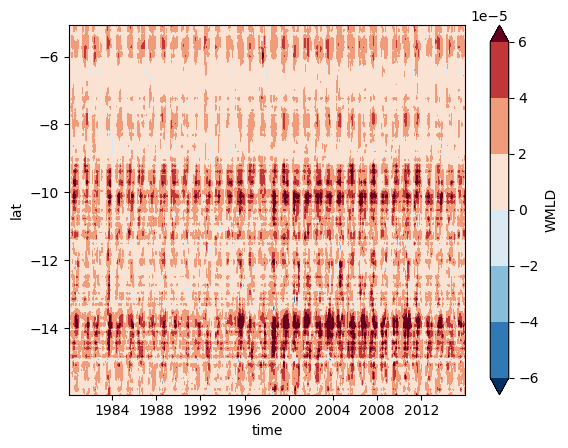

In [88]:
(WMLD_ds_.WMLD * inshore_mask).mean(dim='lon').sel(lat=slice(-16,-5)).plot.contourf(x='time',robust=True)

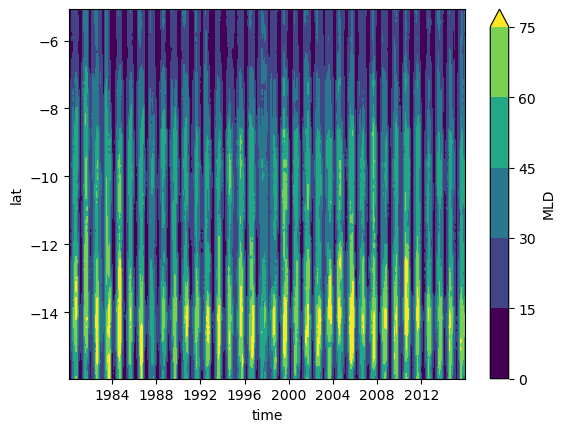

In [103]:
(MLD_ds.MLD * inshore_mask).mean(dim='lon').sel(lat=slice(-16,-5)).plot.contourf(x='time',robust=True)

In [81]:
SV = (WMLD_ds_.WMLD * D *10**3 * MLD_ds.MLD)/10**6
SV

<xarray.DataArray (time: 432, lat: 542, lon: 602)> Size: 1GB
array([[[ 1.70768251e-07,  1.70505135e-07,  1.48474808e-06, ...,
                     nan,             nan,             nan],
        [ 1.70962245e-07,  1.70699129e-07,  1.48644024e-06, ...,
                     nan,             nan,             nan],
        [-4.10692646e-06, -4.10061294e-06,  2.87073445e-06, ...,
                     nan,             nan,             nan],
        ...,
        [ 3.74491621e-04,  3.73488855e-04, -5.30173511e-04, ...,
                     nan,             nan,             nan],
        [-5.61172603e-04, -5.59545827e-04, -6.03177314e-04, ...,
                     nan,             nan,             nan],
        [-5.58700817e-04, -5.56997637e-04, -6.00422997e-04, ...,
                     nan,             nan,             nan]],

       [[ 8.93230213e-05,  8.91853942e-05, -6.85509788e-04, ...,
                     nan,             nan,             nan],
        [ 8.94244928e-05,  8.92868656e-05, -6.86291058e-04, ...,
                     nan,             nan,             nan],
        [ 1.49874344e-03,  1.49643944e-03, -9.54560941e-04, ...,
                     nan,             nan,             nan],
...
        [ 4.36141213e-05,  4.34973369e-05, -5.25478023e-05, ...,
                     nan,             nan,             nan],
        [-4.12753818e-04, -4.11557292e-04, -2.54964740e-04, ...,
                     nan,             nan,             nan],
        [-4.10935770e-04, -4.09683047e-04, -2.53800482e-04, ...,
                     nan,             nan,             nan]],

       [[-6.79477803e-04, -6.78430877e-04,  1.38067823e-04, ...,
                     nan,             nan,             nan],
        [-6.80249694e-04, -6.79202768e-04,  1.38225178e-04, ...,
                     nan,             nan,             nan],
        [-5.73762176e-04, -5.72880140e-04,  2.23925628e-04, ...,
                     nan,             nan,             nan],
        ...,
        [-7.27277078e-04, -7.25329667e-04, -1.57287924e-04, ...,
                     nan,             nan,             nan],
        [-3.14270030e-03, -3.13358996e-03, -1.28645305e-03, ...,
                     nan,             nan,             nan],
        [-3.12885771e-03, -3.11931950e-03, -1.28057866e-03, ...,
                     nan,             nan,             nan]]])
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

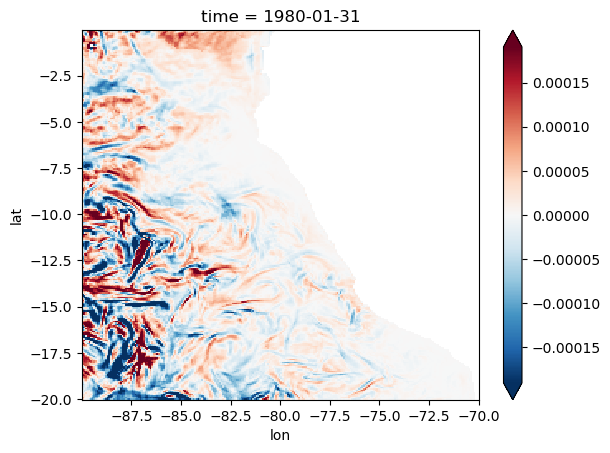

In [79]:
SV.isel(time=0).sel(lat=slice(-20,0),lon=slice(-90,-70)).plot(robust=True)
## it grows offshore due to D 

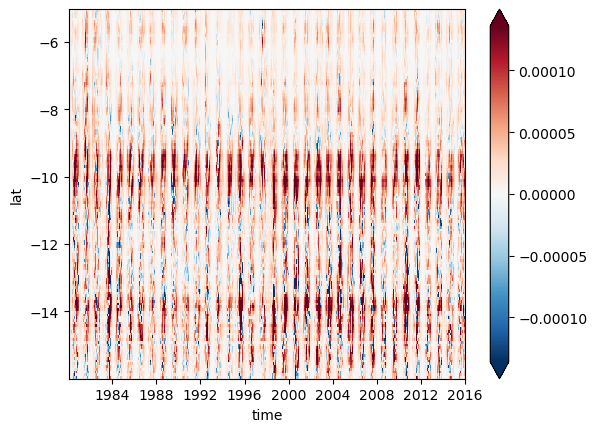

In [80]:
(SV*inshore_mask).mean(dim='lon',skipna=True).sel(lat=slice(-16,-5)).plot(x='time',robust=True)

### Sverdrup calculation 

* This is the right way = w * Area

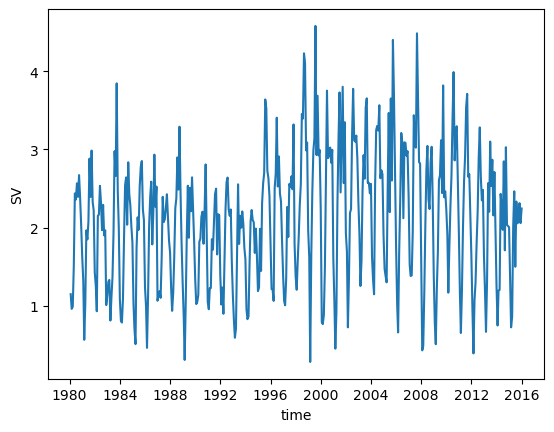

In [123]:
area_grid = 9*9*10**6 #m
grid_n = (111/9) * (16-5)*(111/9) #number of gridcells in the total area
area_total = area_grid * grid_n

(WMLD_ds_.WMLD*inshore_mask * area_total/ 10**6).mean('lon').sel(lat=slice(-16,-5)).mean('lat').rename('SV').plot()

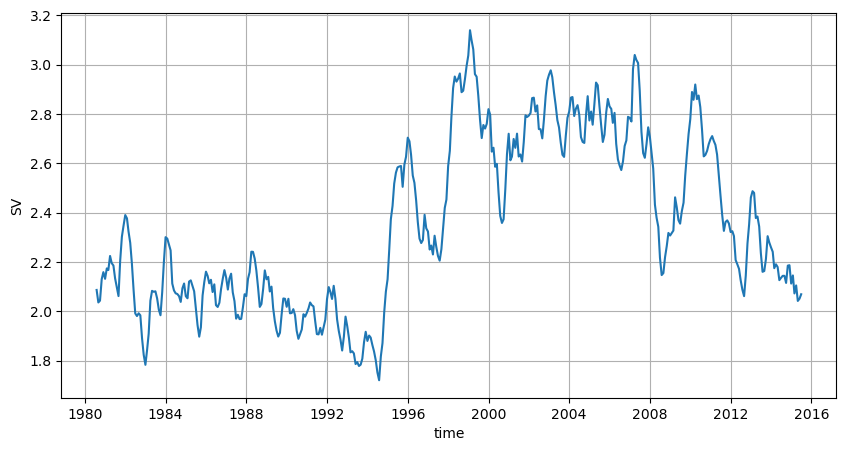

In [131]:
# Approximate grid cell area (m²)
area_grid = 9 * 9 * 1e6  # m² per 1/12° cell at ~15°S

# Upwelling transport [m³/s] per grid cell
Q = WMLD_ds_.WMLD * inshore_mask * area_grid   # NaNs are preserved by default

# Total transport in Sverdrups
Q_Sv = Q.sel(lat=slice(-16,-5)).sum(dim=['lat', 'lon']) / 1e6  # [Sv]

Q_Sv.rename('SV').rolling(time=13,center=True).mean().plot(figsize=(10,5))
plt.grid()

In [127]:
Q_Sv

<xarray.DataArray 'WMLD' (time: 432)> Size: 3kB
array([1.30394897, 1.10723463, 1.12076579, 1.68559492, 2.69802523,
       2.6885206 , 2.7616712 , 2.54659033, 2.94232185, 2.61626583,
       2.28496217, 1.87596291, 1.49410041, 0.64427687, 1.20414389,
       2.25149928, 2.05600944, 2.34417092, 3.2379653 , 2.67761715,
       3.28796739, 2.56222966, 2.49170981, 1.61186711, 1.40024068,
       1.03364161, 2.49269616, 2.47901177, 2.8358638 , 2.61647833,
       2.17209627, 2.54763691, 2.07839128, 2.20460807, 1.15453065,
       1.26203529, 1.47403961, 1.54523699, 0.92855509, 1.28277694,
       1.60551383, 2.30923064, 3.42271588, 3.00041032, 4.29764124,
       2.59076559, 2.15494495, 1.18034659, 0.88646284, 0.87879468,
       1.25410663, 2.14927032, 2.85950555, 2.92293315, 2.23112305,
       3.12725005, 2.67445562, 2.55171633, 2.22893479, 2.00278476,
       1.14410125, 0.77244233, 0.57669049, 1.97184193, 2.40116697,
       2.18970246, 2.81473055, 3.11097584, 3.18971527, 2.38745523,
       2.26571723, 1.36498428, 1.09346428, 0.52607912, 1.26813673,
       2.25360669, 2.6657319 , 2.95869586, 1.95917635, 2.43131296,
       3.29711721, 2.54402118, 2.79191299, 1.1696349 , 1.26988124,
       1.31496746, 1.24532871, 1.81302958, 2.71015915, 2.27550484,
       2.32404112, 2.5344145 , 2.6923918 , 2.31273201, 2.08277105,
       1.86793787, 1.3731331 , 1.04260881, 1.32888908, 1.85802631,
...
       1.78779394, 0.48181898, 0.55478911, 1.34180424, 2.29745113,
       3.10697972, 3.37147951, 2.58397806, 2.53862177, 3.17407132,
       3.41672831, 2.65360135, 1.51747551, 0.87030848, 0.58676795,
       1.39156263, 1.92966357, 2.98890729, 2.97001435, 3.51306642,
       2.7037531 , 4.28911042, 2.65204895, 2.73467529, 2.47138665,
       2.17753898, 1.31382505, 2.01242602, 2.54453601, 2.96857438,
       3.77683752, 4.396756  , 3.10457075, 3.50700803, 3.51778604,
       2.8429537 , 2.12757285, 1.29352619, 0.75677114, 1.39157023,
       2.22457317, 2.90085045, 3.22622416, 3.94183673, 4.15098071,
       2.88691499, 2.99354433, 2.42483322, 1.80771737, 1.09112681,
       0.44117307, 1.22684812, 1.47622998, 2.05885542, 2.44902552,
       3.27256743, 3.68462508, 2.88564875, 2.66837832, 2.75021073,
       1.82187042, 1.31199422, 0.7507232 , 1.51943979, 2.92396598,
       2.48783664, 3.4675686 , 2.78372165, 3.18323603, 2.36073975,
       2.96442031, 2.13949971, 1.35669428, 0.83152585, 1.35368508,
       1.38258375, 2.72272788, 2.59024592, 2.23261802, 3.23433819,
       1.92027152, 3.38853164, 2.21426711, 2.27495037, 2.26005555,
       1.46414383, 0.83101519, 0.98093887, 2.29324684, 2.74487567,
       1.62369328, 2.65897899, 2.2878212 , 2.34127633, 2.57156944,
       2.33320901, 2.50853943])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31

In [133]:
A = 6371.0e3
ndelta_y = -(np.deg2rad(WMLD_ds_.lat.shift(lat=-1) - WMLD_ds_.lat) * A)
ndelta_y

ndelta_x = (
    np.deg2rad(WMLD_ds_.lon.shift(lon=-1) - WMLD_ds_.lon) * A
    * np.cos(np.deg2rad(WMLD_ds_.lat))
)
ndelta_x

da = ndelta_x * ndelta_y
da

<xarray.DataArray (lon: 602, lat: 542)> Size: 3MB
array([[-60393508.1630613 , -60489136.9802803 , -60584736.85856673, ...,
        -83341065.72087006, -83299349.73643497,                nan],
       [-60393508.1630716 , -60489136.98029062, -60584736.85857707, ...,
        -83341065.72088428, -83299349.73644918,                nan],
       [-60393508.1630613 , -60489136.9802803 , -60584736.85856673, ...,
        -83341065.72087006, -83299349.73643497,                nan],
       ...,
       [-60393508.1630716 , -60489136.98029062, -60584736.85857707, ...,
        -83341065.72088428, -83299349.73644918,                nan],
       [-60393508.1630613 , -60489136.9802803 , -60584736.85856673, ...,
        -83341065.72087006, -83299349.73643497,                nan],
       [               nan,                nan,                nan, ...,
                       nan,                nan,                nan]])
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03

In [181]:
total_ep = WMLD_ds_.WMLD * da *inshore_mask
tp1 = -total_ep.sel(lat=slice(-16,-5)).sum(['lon','lat']) / 1e6

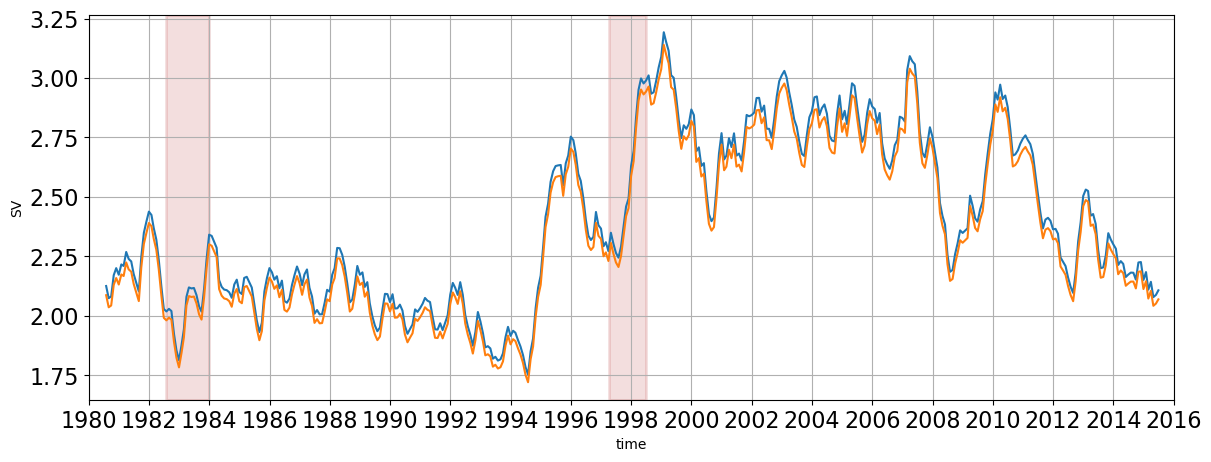

In [182]:
import matplotlib.dates as mdates
import datetime
from matplotlib.patches import Rectangle

tp1.rename('SV').rolling(time=13,center=True).mean().plot(figsize=(14,5))
Q_Sv.rename('SV').rolling(time=13,center=True).mean().plot()
plt.grid()

ax = plt.gca()
#rectangle 1
start_date = datetime.datetime(1982, 8, 1)
end_date = datetime.datetime(1983, 12, 31)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

#rectangle 2
start_date = datetime.datetime(1997, 4, 1)
end_date = datetime.datetime(1998, 6, 30)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

# Set x-axis limits
plt.xlim([mdates.date2num(datetime.datetime(1980, 1, 1)), 
          mdates.date2num(datetime.datetime(2016, 1, 1))])

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))  # Grid lines every 2 years
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format years as 'YYYY'

ax.tick_params(axis='both', which='major', labelsize=16)
plt.grid(visible=True, which='major')

### Winds winds 

In [142]:
new_w = loadmat("../../NHCS/Processed/new_winds.mat")
print(new_w.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Taux', 'Tauy', 'None', 'uwind', 'vwind', '__function_workspace__'])


In [144]:
winds_ds = xr.Dataset(
    data_vars={
        'u10': (("time", "lat","lon"), new_w['uwind'].transpose(2, 1, 0)),
        'v10':(("time", "lat","lon"), new_w['vwind'].transpose(2, 1, 0))
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

winds_ds

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    u10      (time, lat, lon) float64 1GB 1.432 1.435 1.439 ... nan nan nan
    v10      (time, lat, lon) float64 1GB -0.9696 -0.999 -1.031 ... nan nan nan

In [147]:
ws = np.sqrt(winds_ds.u10**2 + winds_ds.v10**2)
omega = 7.29e-5
f = 2 * omega * np.sin(np.radians(winds_ds.lat))
pa = 1.22
cd = 1.3e-3
taux = pa * cd * ws * winds_ds.u10
tauy = pa * cd * ws * winds_ds.v10

In [148]:
delta_y = np.deg2rad(winds_ds.lat.shift(lat=-1) - winds_ds.lat) * A
delta_x = (
    np.deg2rad(winds_ds.lon.shift(lon=-1) - winds_ds.lon) * A
    * np.cos(np.deg2rad(winds_ds.lat))
)

In [149]:
dtauy_by_dx = (tauy.shift(lon=-1) - tauy) / delta_x
dtauy_by_dx = (dtauy_by_dx.shift(lat=-1) + dtauy_by_dx) / 2.0

In [150]:
dtaux_by_dy = (taux.shift(lat=-1) - taux) / delta_y
dtaux_by_dy = (dtaux_by_dy.shift(lon=-1) + dtaux_by_dy) / 2.0

In [151]:
lon1 = (winds_ds.lon.shift(lon=-1) + winds_ds.lon) / 2
lat1 = (winds_ds.lat.shift(lat=-1) + winds_ds.lat) / 2

In [152]:
dtaux_by_dy = dtaux_by_dy.assign_coords(lon = lon1, lat = lat1).isel(lon=slice(None, -1),lat=slice(None, -1))
dtauy_by_dx = dtauy_by_dx.assign_coords(lon = lon1, lat = lat1).isel(lon=slice(None, -1),lat=slice(None, -1))

In [153]:
curlz_tau = (dtauy_by_dx - dtaux_by_dy)
curlz_tau

<xarray.DataArray (time: 432, lat: 541, lon: 601)> Size: 1GB
array([[[-2.21591530e-08, -2.56262787e-08, -2.82245375e-08, ...,
                     nan,             nan,             nan],
        [-2.18795458e-08, -2.51577778e-08, -2.72885023e-08, ...,
                     nan,             nan,             nan],
        [-2.11160759e-08, -2.40432366e-08, -2.56554071e-08, ...,
                     nan,             nan,             nan],
        ...,
        [-2.74339585e-09, -5.33273391e-09, -4.76234302e-09, ...,
                     nan,             nan,             nan],
        [-6.14081958e-09, -8.55689885e-09, -8.01348768e-09, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[-2.02955658e-08, -1.95111345e-08, -1.82613808e-08, ...,
                     nan,             nan,             nan],
        [-1.95366821e-08, -1.83943290e-08, -1.70985476e-08, ...,
                     nan,             nan,             nan],
        [-1.83959413e-08, -1.71509259e-08, -1.60450288e-08, ...,
                     nan,             nan,             nan],
...
        [ 4.96363750e-10,  4.73813263e-10,  6.18057738e-10, ...,
                     nan,             nan,             nan],
        [ 1.17068533e-10,  9.80384106e-11,  2.10567924e-10, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[-3.39051896e-09, -3.80263388e-09, -4.00107796e-09, ...,
                     nan,             nan,             nan],
        [-3.20302789e-09, -3.65630222e-09, -3.93179298e-09, ...,
                     nan,             nan,             nan],
        [-3.19497516e-09, -3.76391996e-09, -4.17216934e-09, ...,
                     nan,             nan,             nan],
        ...,
        [ 1.97714066e-07,  1.96054537e-07,  1.97519937e-07, ...,
                     nan,             nan,             nan],
        [ 1.98937437e-07,  1.98859865e-07,  2.01930072e-07, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 5kB -118.9 -118.8 -118.7 ... -69.08 -68.99 -68.91
  * lat      (lat) float64 4kB -32.97 -32.9 -32.83 -32.76 ... 9.828 9.91 9.992

In [154]:
f = 2 * 7.2921e-5 * np.sin(np.deg2rad(curlz_tau.lat))
rho = 1000
f.shape

(541,)

In [155]:
import cmocean
import cartopy
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cft

In [169]:
w_ek = (1/f/rho) * curlz_tau

w_ek = w_ek.transpose('time','lat','lon')
w_ek

<xarray.DataArray (time: 432, lat: 541, lon: 601)> Size: 1GB
array([[[ 2.79235046e-07,  3.22925481e-07,  3.55667026e-07, ...,
                     nan,             nan,             nan],
        [ 2.76231577e-07,  3.17619602e-07,  3.44520225e-07, ...,
                     nan,             nan,             nan],
        [ 2.67097197e-07,  3.04122846e-07,  3.24515187e-07, ...,
                     nan,             nan,             nan],
        ...,
        [-1.10207671e-07, -2.14226534e-07, -1.91312797e-07, ...,
                     nan,             nan,             nan],
        [-2.44665088e-07, -3.40927523e-07, -3.19276710e-07, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[ 2.55751348e-07,  2.45866462e-07,  2.30117889e-07, ...,
                     nan,             nan,             nan],
        [ 2.46652676e-07,  2.32230347e-07,  2.15870969e-07, ...,
                     nan,             nan,             nan],
        [ 2.32690221e-07,  2.16942023e-07,  2.02953533e-07, ...,
                     nan,             nan,             nan],
...
        [ 1.99399197e-08,  1.90340218e-08,  2.48286094e-08, ...,
                     nan,             nan,             nan],
        [ 4.66429317e-09,  3.90608714e-09,  8.38953483e-09, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[ 4.27250860e-08,  4.79182868e-08,  5.04189483e-08, ...,
                     nan,             nan,             nan],
        [ 4.04385656e-08,  4.61612018e-08,  4.96393018e-08, ...,
                     nan,             nan,             nan],
        [ 4.04132336e-08,  4.76098151e-08,  5.27737606e-08, ...,
                     nan,             nan,             nan],
        ...,
        [ 7.94256753e-06,  7.87590094e-06,  7.93476898e-06, ...,
                     nan,             nan,             nan],
        [ 7.92614812e-06,  7.92305745e-06,  8.04538193e-06, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]]])
Coordinates:
  * lat      (lat) float64 4kB -32.97 -32.9 -32.83 -32.76 ... 9.828 9.91 9.992
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 5kB -118.9 -118.8 -118.7 ... -69.08 -68.99 -68.91

In [170]:
inshore_mask[:-1,:-1].shape

(541, 601)

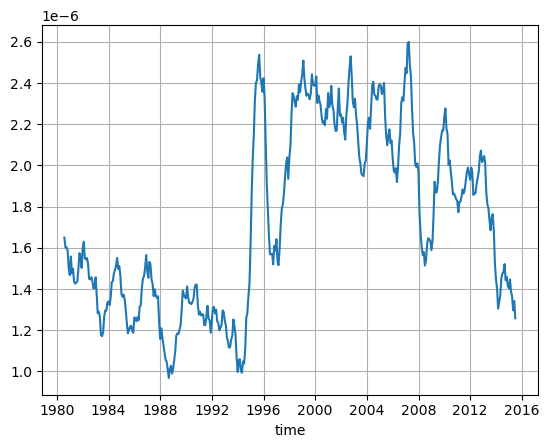

In [196]:
(w_ek * inshore_mask[:-1,:-1]).sel(lat=slice(-16,-5)).mean(dim=('lat','lon')).rolling(time=13,center=True).mean().plot()
plt.grid()

In [207]:
A = 6371.0e3
ndelta_y = (np.deg2rad(w_ek.lat.shift(lat=-1) - w_ek.lat) * A)

ndelta_x = (
    np.deg2rad(w_ek.lon.shift(lon=-1) - w_ek.lon) * A
    * np.cos(np.deg2rad(w_ek.lat))
)


dd = ndelta_x * ndelta_y
dd

total_wek = w_ek * inshore_mask[:-1,:-1] * dd
sv_wek = total_wek.sel(lat=slice(-16,-5)).sum(['lon','lat']) / 1e6

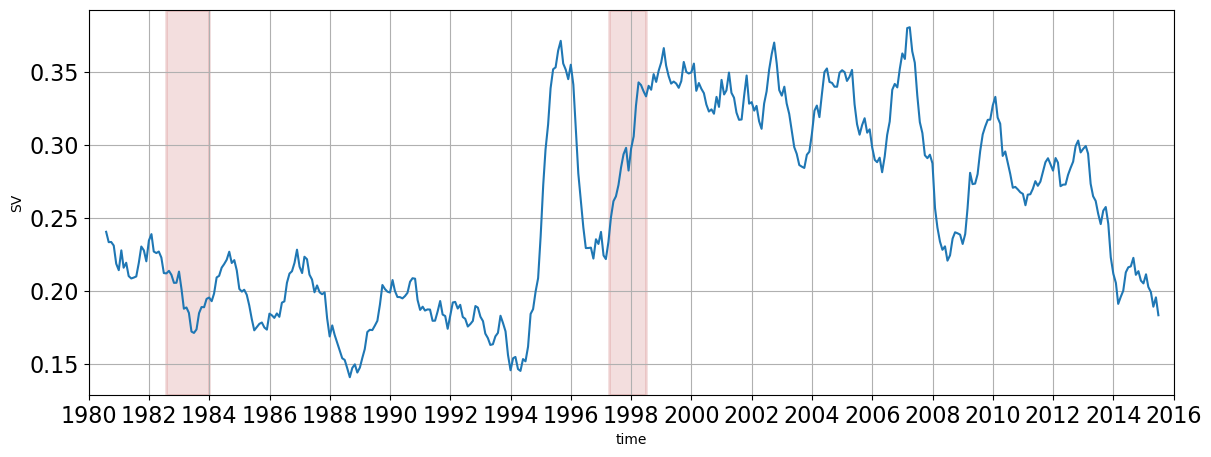

In [211]:
# tp1.rename('SV').rolling(time=13,center=True).mean().plot(figsize=(14,5))
sv_wek.rename('SV').rolling(time=13,center=True).mean().plot(figsize=(14,5))
plt.grid()

ax = plt.gca()
#rectangle 1
start_date = datetime.datetime(1982, 8, 1)
end_date = datetime.datetime(1983, 12, 31)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

#rectangle 2
start_date = datetime.datetime(1997, 4, 1)
end_date = datetime.datetime(1998, 6, 30)
rect = Rectangle(
    (start_date, ax.get_ylim()[0]),  # Bottom-left corner
    end_date - start_date,           # Width (time duration)
    ax.get_ylim()[1] - ax.get_ylim()[0],  # Height (full y-range)
    linewidth=2,
    edgecolor='firebrick',
    facecolor='firebrick',  # Fully transparent
    linestyle='-',    # Dashed border
    alpha=0.15         # Slightly transparent border
)
ax.add_patch(rect)

# Set x-axis limits
plt.xlim([mdates.date2num(datetime.datetime(1980, 1, 1)), 
          mdates.date2num(datetime.datetime(2016, 1, 1))])

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))  # Grid lines every 2 years
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format years as 'YYYY'

ax.tick_params(axis='both', which='major', labelsize=16)
plt.grid(visible=True, which='major')